# Adversarial attacks on an image classifier

This notebook trains a small CNN on MNIST, then attacks it with the fast gradient sign method (FGSM), the basic iterative method (BIM), and the iterative least-likely-class attack. It measures how accuracy collapses as the L-infinity perturbation budget epsilon grows, and shows adversarial examples that are visually almost unchanged yet misclassified.

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import torch

from advattack.attacks import bim, fgsm, iterative_least_likely
from advattack.data import image_loaders
from advattack.model import SmallCNN
from advattack.train import Trainer, accuracy, robust_accuracy, set_seed

set_seed(0)

## Train the victim classifier

MNIST downloads through torchvision on first use. We subsample and train for a few epochs to keep the notebook fast.

In [2]:
train_loader, test_loader = image_loaders('mnist', root='../data', subset=6000)
model = Trainer(SmallCNN(), lr=1e-3).fit(train_loader, epochs=3).model
print('clean test accuracy:', round(accuracy(model, test_loader), 4))

epoch   1  train_loss=1.1836


epoch   2  train_loss=0.3931


epoch   3  train_loss=0.2313


clean test accuracy: 0.963


## Robustness vs epsilon

For each budget we measure accuracy under all three attacks. The iterative methods search harder than single-step FGSM, so they drive accuracy lower at the same epsilon.

In [3]:
EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
curves = {'fgsm': [], 'bim': [], 'ill': []}
for eps in EPSILONS:
    curves['fgsm'].append(robust_accuracy(model, test_loader, partial(fgsm, epsilon=eps)))
    curves['bim'].append(robust_accuracy(model, test_loader, partial(bim, epsilon=eps)))
    curves['ill'].append(robust_accuracy(model, test_loader,
                          lambda m, x, y, e=eps: iterative_least_likely(m, x, e)))
    print(f"eps={eps:.2f}  fgsm={curves['fgsm'][-1]:.4f}  "
          f"bim={curves['bim'][-1]:.4f}  least_likely={curves['ill'][-1]:.4f}")

eps=0.00  fgsm=0.9630  bim=0.9630  least_likely=0.9630


eps=0.05  fgsm=0.9080  bim=0.8940  least_likely=0.9570


eps=0.10  fgsm=0.7930  bim=0.7160  least_likely=0.9390


eps=0.15  fgsm=0.5980  bim=0.3895  least_likely=0.8660


eps=0.20  fgsm=0.3780  bim=0.1000  least_likely=0.6240


eps=0.30  fgsm=0.0870  bim=0.0000  least_likely=0.0550


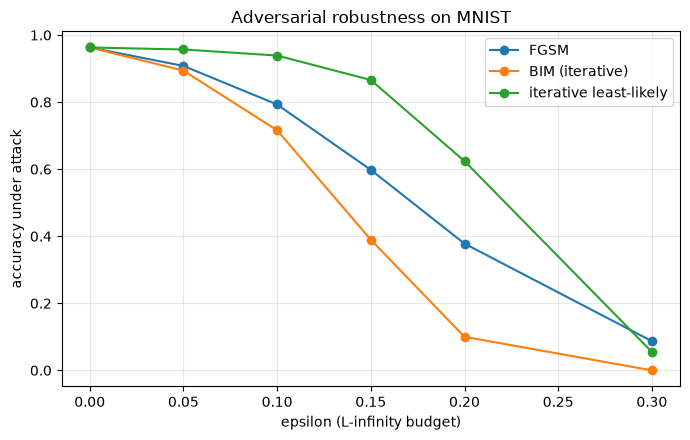

In [4]:
labels = {'fgsm': 'FGSM', 'bim': 'BIM (iterative)', 'ill': 'iterative least-likely'}
plt.figure(figsize=(7, 4.5))
for key, curve in curves.items():
    plt.plot(EPSILONS, curve, marker='o', label=labels[key])
plt.xlabel('epsilon (L-infinity budget)')
plt.ylabel('accuracy under attack')
plt.title('Adversarial robustness on MNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Adversarial examples

Top row: clean digits with the model's prediction. Bottom row: the same digits after an FGSM perturbation of epsilon=0.2, with the new prediction. The perturbations are small in pixel space but flip many predictions.

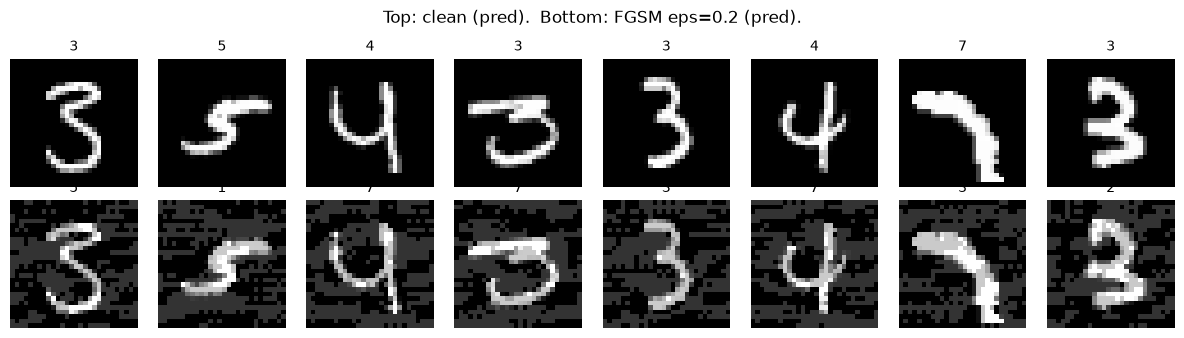

7 of 8 predictions changed under the attack


In [5]:
x, y = next(iter(test_loader))
x, y = x[:8], y[:8]
x_adv = fgsm(model, x, y, epsilon=0.2)
with torch.no_grad():
    clean_pred = model(x).argmax(dim=1)
    adv_pred = model(x_adv).argmax(dim=1)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(x[i, 0], cmap='gray'); axes[0, i].axis('off')
    axes[0, i].set_title(f'{int(clean_pred[i])}', fontsize=10)
    axes[1, i].imshow(x_adv[i, 0], cmap='gray'); axes[1, i].axis('off')
    axes[1, i].set_title(f'{int(adv_pred[i])}', fontsize=10)
fig.suptitle('Top: clean (pred).  Bottom: FGSM eps=0.2 (pred).')
plt.tight_layout()
plt.show()

flipped = int((clean_pred != adv_pred).sum())
print(f'{flipped} of 8 predictions changed under the attack')